# Notebook 11 · Crypto Real-Data Pipeline — Tardis LOB Edition
### Download · Clean · Calibrate · Export (BTC, ETH)

**Source:** Tardis.dev — Binance Futures `book_snapshot_5` (true L1 best bid/ask) + `trades`

---

## Calibration philosophy

### Why the old histogram approach was wrong

The original method computed $\Lambda(\delta_\text{bin}) \approx
\text{count\_of\_trades\_in\_bin}\;/\;\text{total\_seconds}$.
This conflates **how often trades happen *at* a distance $\delta$** with
**how much time the market maker was *exposed* at that distance**.

### Why top-of-book exposure was also insufficient

A second iteration used proper Poisson exposure time but took
$\delta_i = \text{ask}_i - \text{mid}_i$ (the observed best-ask distance).
Since $\text{mid} = (\text{ask}+\text{bid})/2$, this $\delta$ is just
the current half-spread — a single point that changes only when the book
updates.  It does **not** represent a quote distance freely chosen by a
market maker.

### Correct method: hypothetical-quote MLE (Guéant 2017, §6)

In the Guéant framework, $\Lambda(\delta)$ is the fill intensity for a
**hypothetical limit order placed at distance $\delta$ from mid**.

We calibrate $A$ and $k$ by constructing a **grid of hypothetical quote
distances** $\delta_1, \dots, \delta_m$ and asking, for each $\delta_j$
and each LOB interval $[t_i, t_{i+1})$:

1. **Is the quote passive?** — i.e. $\delta_j \ge \text{half-spread}_i$
   (otherwise the quote would be inside the spread and immediately
   marketable).
2. **Would it have been hit?** — did a buy (sell) aggressor trade reach a
   price $\ge \text{mid}_i + \delta_j$ (resp. $\le \text{mid}_i -
   \delta_j$) during $[t_i, t_{i+1})$?

For each $\delta_j$ we accumulate:

$$E_j = \sum_{i:\;\delta_j \ge \text{hs}_i} \Delta t_i, \qquad N_j = \sum_{i:\;\delta_j \ge \text{hs}_i} \mathbf{1}\bigl[\text{hit}_i(\delta_j)\bigr].$$

The log-likelihood for $\Lambda(\delta) = A\,e^{-k\delta}$:

$$\ell(A,k) = \sum_j \bigl[ N_j \ln\bigl(A\,e^{-k\delta_j}\bigr) - E_j\,A\,e^{-k\delta_j} \bigr].$$

Profile MLE in $k$ gives $A^*(k) = \sum N_j \big/ \sum E_j\,e^{-k\delta_j}$
and a smooth 1-D optimisation solved with `scipy.optimize.minimize_scalar`.

> **Remaining limitation.** With L1 data only we cannot observe queue
> position; we assume that any aggressive trade reaching the hypothetical
> quote price would fill us.  This is standard for a coursework-level
> calibration and is stated explicitly in the report.

## 0. Imports and Configuration

In [1]:
import gzip
import json
import pickle
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import requests
from scipy.optimize import minimize_scalar

warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8")
%matplotlib inline

import sys
sys.path.append(str(Path().resolve().parents[0]))

from market_making.core.intensity import C_coeff

In [2]:
SYMBOLS = ["BTCUSDT", "ETHUSDT"]

FREE_DAYS = [
    "2025-03-01", "2025-02-01", "2025-01-01",
    "2024-12-01", "2024-11-01", "2024-10-01",
]

RAW_DIR  = Path("data/tardis_raw")
OUT_DIR  = Path("data/calibrated")
CKPT_DIR = OUT_DIR / "checkpoints_tardis"

for d in [RAW_DIR, OUT_DIR, CKPT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

LOT_SIZES = {"BTCUSDT": 0.001, "ETHUSDT": 0.01}
Q_MAX     = 4
GAMMA     = 1e-6
FORCE_RERUN = True

TARDIS_EXCHANGE = "binance-futures"
TARDIS_BASE     = "https://datasets.tardis.dev/v1"

# Number of hypothetical delta grid points for MLE
N_DELTA_GRID = 25

print(f"Symbols : {', '.join(SYMBOLS)}")
print(f"Days    : {len(FREE_DAYS)} free-tier (1st of month)")

Symbols : BTCUSDT, ETHUSDT
Days    : 6 free-tier (1st of month)


## 1. Check for Existing Outputs

In [3]:
def outputs_complete(symbols, out_dir):
    return (
        (out_dir / "calibrated_params.json").exists()
        and all((out_dir / f"mid_prices_{s}.parquet").exists() for s in symbols)
        and all((out_dir / f"daily_stats_{s}.csv").exists() for s in symbols)
    )

PIPELINE_DONE = outputs_complete(SYMBOLS, OUT_DIR) and not FORCE_RERUN

calibrated = {}
mid_series = {}

if PIPELINE_DONE:
    print("Loading existing outputs...")
    with open(OUT_DIR / "calibrated_params.json") as f:
        raw = json.load(f)
    for sym in SYMBOLS:
        if sym in raw:
            calibrated[sym] = dict(raw[sym])
        pq = OUT_DIR / f"mid_prices_{sym}.parquet"
        if pq.exists():
            mid_series[sym] = pd.read_parquet(pq)["mid_price"]
    if "cross_correlation" in raw:
        calibrated["rho"] = raw["cross_correlation"].get("rho")
    for sym in SYMBOLS:
        if sym in calibrated:
            print(f"  {sym}: A={calibrated[sym]['A']:.6f}, k={calibrated[sym]['k']:.4f}")
else:
    print("Full pipeline will run.")

Full pipeline will run.


## 2. Download Functions

In [4]:
def tardis_local_path(data_type, symbol, date_str):
    p = RAW_DIR / symbol
    p.mkdir(exist_ok=True)
    return p / f"{data_type}_{date_str}.csv.gz"


def download_tardis(data_type, symbol, date_str):
    local = tardis_local_path(data_type, symbol, date_str)
    if local.exists():
        return local
    y, m, d = date_str.split("-")
    url = f"{TARDIS_BASE}/{TARDIS_EXCHANGE}/{data_type}/{y}/{m}/{d}/{symbol}.csv.gz"
    try:
        resp = requests.get(url, timeout=180)
    except Exception as e:
        print(f"    [ERROR] {e}")
        return None
    if resp.status_code == 200:
        local.write_bytes(resp.content)
        return local
    try:
        msg = resp.json().get("message", resp.text[:200])
    except Exception:
        msg = resp.text[:200]
    print(f"    [SKIP] HTTP {resp.status_code}: {msg}")
    return None

## 3. Download All Data

In [5]:
if PIPELINE_DONE:
    print("Download skipped.")
else:
    for symbol in SYMBOLS:
        print(f"\n{'='*50}\nDownloading {symbol}\n{'='*50}")
        for date_str in FREE_DAYS:
            print(f"  {date_str}")
            for dtype in ["book_snapshot_5", "trades"]:
                p = download_tardis(dtype, symbol, date_str)
                s = f"OK ({p.stat().st_size/1e6:.1f} MB)" if p else "FAILED"
                print(f"    {dtype:20s} -> {s}")


  2025-03-01
    book_snapshot_5      -> OK (26.7 MB)
    trades               -> OK (27.9 MB)
  2025-02-01
    book_snapshot_5      -> OK (21.2 MB)
    trades               -> OK (19.4 MB)
  2025-01-01
    book_snapshot_5      -> OK (19.9 MB)
    trades               -> OK (17.0 MB)
  2024-12-01
    book_snapshot_5      -> OK (22.8 MB)
    trades               -> OK (17.4 MB)
  2024-11-01
    book_snapshot_5      -> OK (27.9 MB)
    trades               -> OK (42.7 MB)
  2024-10-01
    book_snapshot_5      -> OK (30.2 MB)
    trades               -> OK (47.9 MB)

  2025-03-01
    book_snapshot_5      -> OK (38.4 MB)
    trades               -> OK (45.1 MB)
  2025-02-01
    book_snapshot_5      -> OK (31.8 MB)
    trades               -> OK (40.5 MB)
  2025-01-01
    book_snapshot_5      -> OK (26.3 MB)
    trades               -> OK (23.2 MB)
  2024-12-01
    book_snapshot_5      -> OK (29.9 MB)
    trades               -> OK (36.9 MB)
  2024-11-01
    book_snapshot_5      -> OK (30.

## 4. Load Functions

In [6]:
def load_book_snapshot(path):
    # Load Tardis book_snapshot_5.
    # Returns: timestamp, bid, ask, mid, spread (tz-naive UTC).
    # Crossed-book rows (ask <= bid) are removed.
    with gzip.open(path, "rb") as f:
        df = pd.read_csv(f)
    df["timestamp"] = (
        pd.to_datetime(df["timestamp"], unit="us", utc=True).dt.tz_localize(None)
    )
    df["ask"]    = pd.to_numeric(df["asks[0].price"], errors="coerce")
    df["bid"]    = pd.to_numeric(df["bids[0].price"], errors="coerce")
    df["mid"]    = (df["ask"] + df["bid"]) / 2.0
    df["spread"] = df["ask"] - df["bid"]
    df = df.dropna(subset=["ask", "bid"])
    df = df[df["spread"] > 0]
    return (df[["timestamp", "bid", "ask", "mid", "spread"]]
            .sort_values("timestamp").reset_index(drop=True))


def load_trades(path):
    # Load Tardis trades.
    # side='buy'  -> taker bought (hit the ask).
    # side='sell' -> taker sold   (hit the bid).
    with gzip.open(path, "rb") as f:
        df = pd.read_csv(f)
    df["timestamp"] = (
        pd.to_datetime(df["timestamp"], unit="us", utc=True).dt.tz_localize(None)
    )
    df["price"]    = pd.to_numeric(df["price"],  errors="coerce")
    df["quantity"] = pd.to_numeric(df["amount"], errors="coerce")
    df = df.dropna(subset=["price", "quantity"])
    return (df[["timestamp", "price", "quantity", "side"]]
            .sort_values("timestamp").reset_index(drop=True))


print("Load functions defined.")

Load functions defined.


## 5. Quick Look on One Sample Day

Sample: 2025-03-01

BTCUSDT: 1,392,526 LOB snaps | 3,014,683 trades | median spread=0.1000 USDT | buy=1,503,608 sell=1,511,075
ETHUSDT: 1,498,817 LOB snaps | 4,872,005 trades | median spread=0.0100 USDT | buy=2,414,381 sell=2,457,624


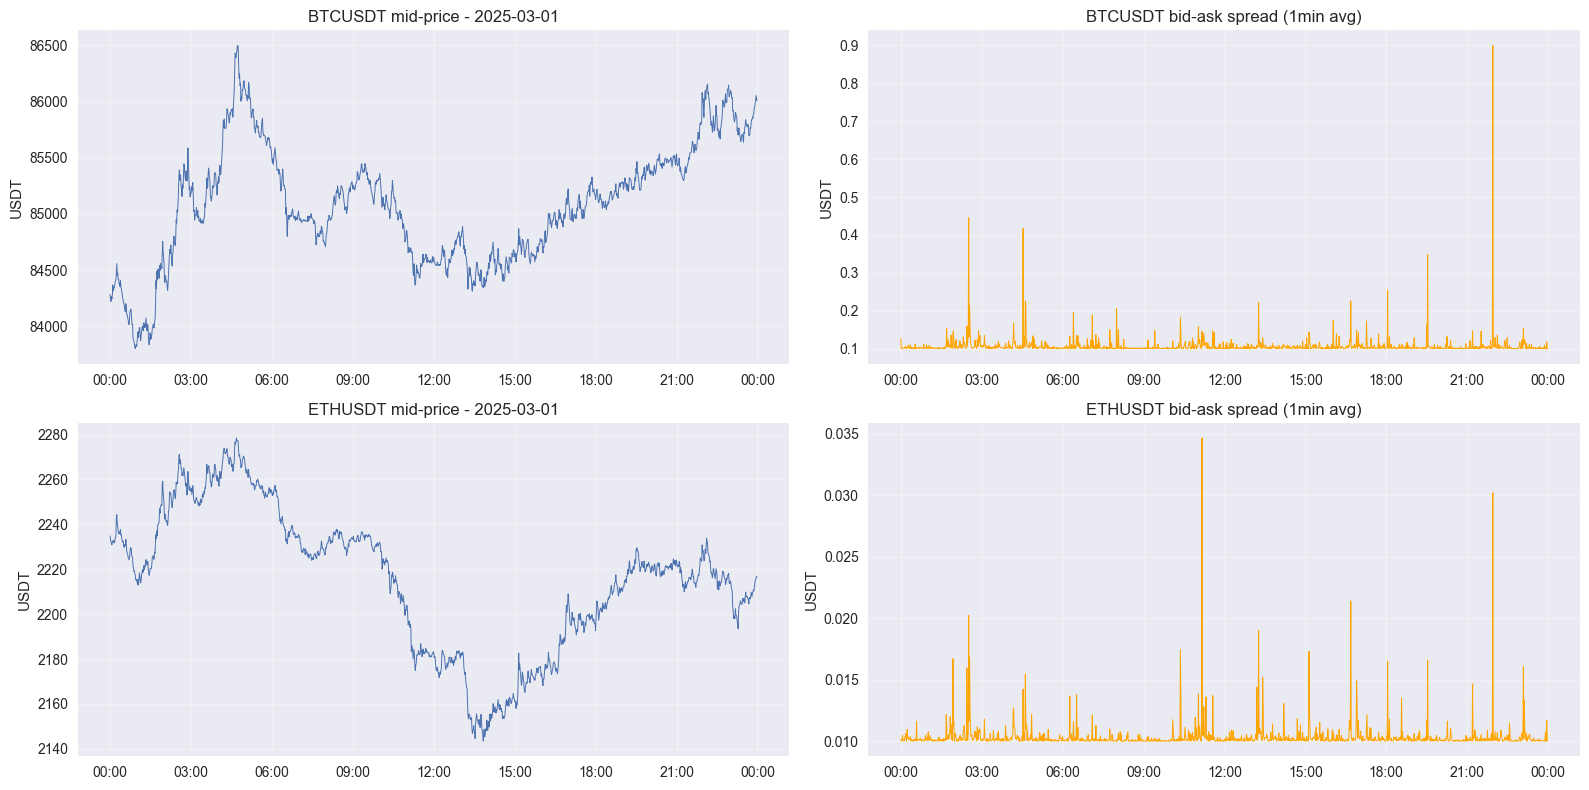

In [7]:
if PIPELINE_DONE:
    print("Quick look skipped.")
else:
    sample_date = FREE_DAYS[0]
    print(f"Sample: {sample_date}\n")
    for symbol in SYMBOLS:
        bp = tardis_local_path("book_snapshot_5", symbol, sample_date)
        tp = tardis_local_path("trades", symbol, sample_date)
        if not bp.exists() or not tp.exists():
            continue
        b = load_book_snapshot(bp)
        t = load_trades(tp)
        print(f"{symbol}: {len(b):,} LOB snaps | {len(t):,} trades | "
              f"median spread={b['spread'].median():.4f} USDT | "
              f"buy={(t['side']=='buy').sum():,} sell={(t['side']=='sell').sum():,}")

    fig, axes = plt.subplots(len(SYMBOLS), 2, figsize=(16, 4 * len(SYMBOLS)))
    if len(SYMBOLS) == 1:
        axes = np.array([axes])
    for row, symbol in enumerate(SYMBOLS):
        bp = tardis_local_path("book_snapshot_5", symbol, sample_date)
        if not bp.exists():
            continue
        b = load_book_snapshot(bp)
        ax = axes[row, 0]
        m = b.set_index("timestamp")["mid"].resample("1min").last().dropna()
        ax.plot(m.index, m.values, lw=0.7)
        ax.set_title(f"{symbol} mid-price - {sample_date}")
        ax.set_ylabel("USDT")
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
        ax.grid(True, alpha=0.3)
        ax = axes[row, 1]
        s = b.set_index("timestamp")["spread"].resample("1min").mean().dropna()
        ax.plot(s.index, s.values, lw=0.7, color="orange")
        ax.set_title(f"{symbol} bid-ask spread (1min avg)")
        ax.set_ylabel("USDT")
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 6. Build LOB Interval Table

For each LOB interval $[t_i, t_{i+1})$ we record the mid-price, half-spread,
and the **extreme aggressive trade prices** within that interval:

| Column | Meaning |
|---|---|
| `mid` | mid-price at LOB snapshot $i$ |
| `half_spread` | $(\text{ask}_i - \text{bid}_i)/2$ |
| `dt` | duration $t_{i+1} - t_i$ in seconds |
| `max_buy_price` | highest buy-aggressor trade price in $[t_i, t_{i+1})$ |
| `min_sell_price` | lowest sell-aggressor trade price in $[t_i, t_{i+1})$ |

These extreme prices tell us, for any hypothetical quote at
$\text{mid}_i + \delta$ (ask) or $\text{mid}_i - \delta$ (bid),
whether that quote **would have been reached** by aggressive flow.

In [8]:
def build_interval_table(book, trades):
    '''Build LOB intervals and aggregate aggressive trade extremes
    (max buy price, min sell price per interval).'''
    book   = book.sort_values("timestamp").reset_index(drop=True)
    trades = trades.sort_values("timestamp").reset_index(drop=True)

    ts      = book["timestamp"].values
    next_ts = np.empty(len(ts), dtype=ts.dtype)
    next_ts[:-1] = ts[1:]
    next_ts[-1]  = ts[-1]

    dt = (next_ts - ts).astype("int64") / 1e9

    intervals = book.copy()
    intervals["next_ts"]     = pd.Series(next_ts, index=intervals.index)
    intervals["dt"]          = dt
    intervals["half_spread"] = 0.5 * intervals["spread"]

    intervals = intervals[intervals["dt"] > 0].reset_index(drop=True)

    # Assign each trade to the last LOB snapshot before it
    ref = (intervals[["timestamp"]].reset_index()
           .rename(columns={"index": "interval_idx"}))
    merged = pd.merge_asof(
        trades[["timestamp", "price", "side"]].sort_values("timestamp"),
        ref, on="timestamp", direction="backward",
    )
    merged = merged.dropna(subset=["interval_idx"])
    merged["interval_idx"] = merged["interval_idx"].astype(int)

    # Keep only trades strictly inside the interval
    merged["next_ts"] = intervals.loc[
        merged["interval_idx"].values, "next_ts"
    ].values
    merged = merged[merged["timestamp"] < merged["next_ts"]]

    buy_trades  = merged[merged["side"] == "buy"]
    sell_trades = merged[merged["side"] == "sell"]

    max_buy  = buy_trades.groupby("interval_idx")["price"].max()
    min_sell = sell_trades.groupby("interval_idx")["price"].min()

    intervals["max_buy_price"]  = np.nan
    intervals["min_sell_price"] = np.nan

    intervals.loc[max_buy.index,  "max_buy_price"]  = max_buy.values
    intervals.loc[min_sell.index, "min_sell_price"] = min_sell.values

    return intervals[[
        "timestamp", "next_ts", "dt",
        "mid", "bid", "ask", "spread", "half_spread",
        "max_buy_price", "min_sell_price",
    ]]


print("build_interval_table() defined.")

build_interval_table() defined.


## 7. Hypothetical-Quote Grid and Empirical Intensity Curve

We build a grid $\delta_1 < \cdots < \delta_m$ spanning from slightly
below the typical half-spread up to the deepest distances reached by
aggressive trades.

For each $\delta_j$ and side (ask / bid):

- **Exposure**: total time the hypothetical quote would have been
  **passive** ($\delta_j \ge \text{half-spread}_i$).
- **Hits**: number of intervals where an aggressive trade reached the
  hypothetical quote price $\text{mid}_i \pm \delta_j$.

This gives the empirical fill-intensity curve
$\hat\Lambda(\delta_j) = N_j / E_j$ which we then fit with $A\,e^{-k\delta}$.

In [9]:
def make_delta_grid(intervals, n_grid=25):
    '''Build a grid of hypothetical quote distances delta.
    Range: 10th pctile of half-spreads to 99th pctile of trade excursions.'''
    hs = intervals["half_spread"].values
    hs = hs[np.isfinite(hs) & (hs > 0)]

    buy_exc  = intervals["max_buy_price"].values - intervals["mid"].values
    sell_exc = intervals["mid"].values - intervals["min_sell_price"].values

    exc = np.concatenate([
        buy_exc[np.isfinite(buy_exc)  & (buy_exc > 0)],
        sell_exc[np.isfinite(sell_exc) & (sell_exc > 0)],
    ])

    lo = np.quantile(hs, 0.10)
    hi = np.quantile(exc, 0.99) if len(exc) > 0 else np.quantile(hs, 0.95) * 3.0
    hi = max(hi, lo * 2.0)

    return np.linspace(lo, hi, n_grid)


def empirical_curve_from_grid(intervals, delta_grid, side):
    '''For each delta in delta_grid compute:
      exposure(delta) -- total seconds the hypothetical quote was passive
      hits(delta)     -- intervals where aggressive flow reached the quote
      lambda_emp(delta) -- hits / exposure

    side: 'ask' or 'bid'
    '''
    mid = intervals["mid"].values
    hs  = intervals["half_spread"].values
    dt  = intervals["dt"].values

    # Broadcast: rows = intervals, cols = grid points
    D   = delta_grid[None, :]            # (1, m)
    MID = mid[:, None]                   # (n, 1)
    HS  = hs[:, None]                    # (n, 1)
    DT  = dt[:, None]                    # (n, 1)

    # Quote is passive only if delta >= half-spread
    eligible = D >= HS                   # (n, m)

    if side == "ask":
        reached = intervals["max_buy_price"].values[:, None]
        quote   = MID + D
        hits = eligible & np.isfinite(reached) & (reached >= quote)
    elif side == "bid":
        reached = intervals["min_sell_price"].values[:, None]
        quote   = MID - D
        hits = eligible & np.isfinite(reached) & (reached <= quote)
    else:
        raise ValueError("side must be 'ask' or 'bid'")

    exposure   = (eligible * DT).sum(axis=0)
    hit_count  = hits.sum(axis=0)

    lambda_emp = np.zeros_like(delta_grid, dtype=float)
    mask       = exposure > 0
    lambda_emp[mask] = hit_count[mask] / exposure[mask]

    return hit_count.astype(float), exposure, lambda_emp


print("Grid and empirical-curve functions defined.")

Grid and empirical-curve functions defined.


## 8. MLE Calibration: $\Lambda(\delta) = A\,e^{-k\delta}$

### Profile likelihood on the hypothetical-quote grid

Given aggregated $(N_j, E_j, \delta_j)$ for each grid point $j$:

$$\ell(A,k) = \sum_j \bigl[ N_j \bigl(\ln A - k\delta_j\bigr) - E_j\,A\,e^{-k\delta_j} \bigr]$$

For fixed $k$, the optimal $A$ is analytic:

$$A^*(k) = \frac{\sum_j N_j}{\sum_j E_j\,e^{-k\delta_j}}.$$

Substituting back gives a smooth 1-D profile in $k$ solved with
`scipy.optimize.minimize_scalar` in $\log k$ space.

In [10]:
def fit_exp_intensity_mle_grid(delta_grid, hits, exposure):
    '''MLE for Lambda(delta) = A * exp(-k * delta) on the hypothetical-quote grid.

    Returns: A_hat, k_hat, R_squared, fitted_lambda
    '''
    d = np.asarray(delta_grid, dtype=float)
    N = np.asarray(hits,       dtype=float)
    E = np.asarray(exposure,   dtype=float)

    mask = (E > 0) & np.isfinite(d)
    d, N, E = d[mask], N[mask], E[mask]

    N_total = N.sum()
    if N_total < 5:
        raise ValueError(f"Too few hits for MLE (N={N_total:.0f})")

    def neg_profile_ll(log_k):
        k = np.exp(log_k)
        denom = np.dot(E, np.exp(-k * d))
        if denom <= 0:
            return 1e15
        A = N_total / denom
        ll = np.sum(N * (np.log(A) - k * d) - A * np.exp(-k * d) * E)
        return -ll

    res = minimize_scalar(
        neg_profile_ll,
        bounds=(-10, 10),
        method="bounded",
        options={"xatol": 1e-9, "maxiter": 2000},
    )

    k_hat = float(np.exp(res.x))
    A_hat = float(N_total / np.dot(E, np.exp(-k_hat * d)))
    lam_fit = A_hat * np.exp(-k_hat * d)

    # Weighted R-squared diagnostic
    lam_emp = np.zeros_like(d)
    pos = E > 0
    lam_emp[pos] = N[pos] / E[pos]
    w = E / E.sum()
    ss_res = np.sum(w * (lam_emp - lam_fit) ** 2)
    ss_tot = np.sum(w * (lam_emp - np.sum(w * lam_emp)) ** 2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else 0.0

    return A_hat, k_hat, float(r2), lam_fit


print("MLE grid fit defined.")

MLE grid fit defined.


## 9. Day-by-Day Processing Loop

For each day we:
1. Load book snapshots and trades.
2. Compute 1-second mid-price returns (for $\sigma$).
3. Build the LOB interval table (mid, half-spread, extreme trade prices).
4. Checkpoint progress to disk.

In [11]:
def save_checkpoint(symbol, state):
    p = CKPT_DIR / f"{symbol}_mle.pkl"
    tmp = p.with_suffix(".tmp")
    with open(tmp, "wb") as f:
        pickle.dump(state, f)
    tmp.replace(p)


def load_checkpoint(symbol):
    p = CKPT_DIR / f"{symbol}_mle.pkl"
    if not p.exists():
        return None
    try:
        with open(p, "rb") as f:
            return pickle.load(f)
    except Exception:
        p.unlink(missing_ok=True)
        return None


pipeline_results = {}

if PIPELINE_DONE:
    print("Processing skipped.")
else:
    for symbol in SYMBOLS:
        print(f"\n{'='*55}\nProcessing {symbol}\n{'='*55}")

        ckpt = load_checkpoint(symbol)
        if ckpt and not FORCE_RERUN:
            print(f"  Resuming from checkpoint ({len(ckpt['processed_dates'])} days)")
            state = ckpt
        else:
            state = {
                "all_mid": [],
                "all_returns": [],
                "interval_tables": [],
                "daily_sigma": [],
                "daily_stats": [],
                "total_seconds": 0.0,
                "total_trades": 0,
                "processed_dates": [],
            }

        done = set(state["processed_dates"])

        for i, date_str in enumerate(FREE_DAYS):
            print(f"  [{i+1}/{len(FREE_DAYS)}] {date_str} ", end="", flush=True)

            if date_str in done:
                print("SKIP (checkpoint)")
                continue

            bp = tardis_local_path("book_snapshot_5", symbol, date_str)
            tp = tardis_local_path("trades",          symbol, date_str)

            if not bp.exists() or not tp.exists():
                print("SKIP (files missing)")
                continue

            try:
                book   = load_book_snapshot(bp)
                trades = load_trades(tp)

                if len(book) < 100 or len(trades) < 100:
                    print("SKIP (too few rows)")
                    continue

                # 1s mid for sigma
                mid_1s  = book.set_index("timestamp")["mid"].resample("1s").last().dropna()
                returns = mid_1s.diff().dropna().values

                # LOB interval table (the new core structure)
                intervals = build_interval_table(book, trades)

                span = (book["timestamp"].max() - book["timestamp"].min()).total_seconds()

                n_buy_trades  = int((trades["side"] == "buy").sum())
                n_sell_trades = int((trades["side"] == "sell").sum())

                state["all_mid"].append(mid_1s)
                state["all_returns"].append(returns)
                state["interval_tables"].append(intervals)

                state["daily_sigma"].append(float(np.std(returns)))
                state["daily_stats"].append({
                    "date":          date_str,
                    "n_trades":      len(trades),
                    "n_book_snaps":  len(book),
                    "n_intervals":   len(intervals),
                    "n_buy_trades":  n_buy_trades,
                    "n_sell_trades": n_sell_trades,
                    "mean_price":    float(book["mid"].mean()),
                    "sigma":         float(np.std(returns)),
                    "spread_median": float(book["spread"].median()),
                    "span_hours":    span / 3600.0,
                })
                state["total_seconds"] += span
                state["total_trades"]  += len(trades)
                done.add(date_str)
                state["processed_dates"] = sorted(done)

                print(
                    f"OK | {len(trades):,} trades | "
                    f"{len(intervals):,} intervals | "
                    f"buy={n_buy_trades:,} sell={n_sell_trades:,}"
                )
                save_checkpoint(symbol, state)

            except Exception as e:
                print(f"ERROR: {e}")

        pipeline_results[symbol] = state
        print(f"  -> total trades : {state['total_trades']:,}")
        print(f"  -> total hours  : {state['total_seconds']/3600:.1f}")


Processing BTCUSDT
  [1/6] 2025-03-01 OK | 3,014,683 trades | 1,392,525 intervals | buy=1,503,608 sell=1,511,075
  [2/6] 2025-02-01 OK | 2,078,447 trades | 1,225,737 intervals | buy=1,029,409 sell=1,049,038
  [3/6] 2025-01-01 OK | 1,804,360 trades | 1,159,377 intervals | buy=902,508 sell=901,852
  [4/6] 2024-12-01 OK | 1,872,343 trades | 1,287,760 intervals | buy=946,603 sell=925,740
  [5/6] 2024-11-01 OK | 4,618,172 trades | 1,373,695 intervals | buy=2,273,038 sell=2,345,134
  [6/6] 2024-10-01 OK | 5,090,124 trades | 1,390,565 intervals | buy=2,499,625 sell=2,590,499
  -> total trades : 18,478,129
  -> total hours  : 144.0

Processing ETHUSDT
  [1/6] 2025-03-01 OK | 4,872,005 trades | 1,498,816 intervals | buy=2,414,381 sell=2,457,624
  [2/6] 2025-02-01 OK | 4,302,084 trades | 1,387,655 intervals | buy=2,177,167 sell=2,124,917
  [3/6] 2025-01-01 OK | 2,495,858 trades | 1,281,887 intervals | buy=1,297,230 sell=1,198,628
  [4/6] 2024-12-01 OK | 3,980,508 trades | 1,415,335 intervals | 

## 10. MLE Calibration: $A$ and $k$ per Symbol

We concatenate all interval tables, build the hypothetical-quote grid,
compute empirical fill intensities, and fit $\Lambda(\delta) = A\,e^{-k\delta}$
independently on the **ask side** and **bid side**.

For the symmetric Guéant model ($\Lambda^a = \Lambda^b = \Lambda$) we
average the two estimates.

In [12]:
fit_cache = {}

if not PIPELINE_DONE:
    for symbol in SYMBOLS:
        res = pipeline_results[symbol]
        if not res["all_mid"]:
            print(f"{symbol}: no data processed, skipping.")
            continue

        # Aggregate mid series
        full_mid = pd.concat(res["all_mid"]).sort_index()
        full_mid = full_mid[~full_mid.index.duplicated(keep="first")]
        mid_series[symbol] = full_mid

        sigma_agg = float(np.std(np.concatenate(res["all_returns"])))

        # Concatenate all interval tables
        all_intervals = pd.concat(res["interval_tables"], ignore_index=True)

        # Build hypothetical-quote grid
        delta_grid = make_delta_grid(all_intervals, n_grid=N_DELTA_GRID)

        print(f"\n{symbol}")
        print(f"  Total intervals : {len(all_intervals):,}")
        print(f"  delta grid      : [{delta_grid[0]:.4f}, {delta_grid[-1]:.4f}] USDT "
              f"({len(delta_grid)} points)")

        # Empirical curves
        hits_ask, exp_ask, lam_emp_ask = empirical_curve_from_grid(
            all_intervals, delta_grid, side="ask")
        hits_bid, exp_bid, lam_emp_bid = empirical_curve_from_grid(
            all_intervals, delta_grid, side="bid")

        print(f"  Ask hits total  : {hits_ask.sum():.0f}")
        print(f"  Bid hits total  : {hits_bid.sum():.0f}")

        # MLE fits
        A_ask, k_ask, r2_ask, lam_fit_ask = fit_exp_intensity_mle_grid(
            delta_grid, hits_ask, exp_ask)
        A_bid, k_bid, r2_bid, lam_fit_bid = fit_exp_intensity_mle_grid(
            delta_grid, hits_bid, exp_bid)

        # Symmetric average
        A_fit  = 0.5 * (A_ask + A_bid)
        k_fit  = 0.5 * (k_ask + k_bid)
        r2_avg = 0.5 * (r2_ask + r2_bid)

        mean_price = float(np.mean([s["mean_price"] for s in res["daily_stats"]]))
        Delta      = round(mean_price * LOT_SIZES[symbol], 2)

        calibrated[symbol] = {
            "sigma": sigma_agg,
            "A": A_fit, "k": k_fit,
            "A_ask": A_ask, "k_ask": k_ask,
            "A_bid": A_bid, "k_bid": k_bid,
            "r_squared": r2_avg,
            "r_squared_ask": r2_ask,
            "r_squared_bid": r2_bid,
            "Delta": Delta, "Q": Q_MAX,
            "mean_price": round(mean_price, 2),
            "lot_size": LOT_SIZES[symbol],
            "n_trades": res["total_trades"],
            "n_days": len(res["daily_stats"]),
            "total_hours": round(res["total_seconds"] / 3600, 1),
            "period": f"{FREE_DAYS[-1]} -> {FREE_DAYS[0]}",
            "source": "Tardis.dev binance-futures L1 + trades, hypothetical quote MLE",
            "calibration_date": datetime.now().strftime("%Y-%m-%d %H:%M"),
        }

        fit_cache[symbol] = {
            "delta_grid":   delta_grid,
            "lam_emp_ask":  lam_emp_ask,
            "lam_fit_ask":  lam_fit_ask,
            "lam_emp_bid":  lam_emp_bid,
            "lam_fit_bid":  lam_fit_bid,
            "daily_sigma":  np.array(res["daily_sigma"]),
        }

        print(f"  Ask MLE : A={A_ask:.6f}, k={k_ask:.4f}, R2={r2_ask:.4f}")
        print(f"  Bid MLE : A={A_bid:.6f}, k={k_bid:.4f}, R2={r2_bid:.4f}")
        print(f"  Avg     : A={A_fit:.6f}, k={k_fit:.4f}, R2={r2_avg:.4f}")
        print(f"  Delta   = {Delta:.2f} $")


BTCUSDT
  Total intervals : 7,829,659
  delta grid      : [0.0500, 7.0500] USDT (25 points)
  Ask hits total  : 2149767
  Bid hits total  : 2137944
  Ask MLE : A=0.653303, k=0.4958, R2=0.3335
  Bid MLE : A=0.638999, k=0.4871, R2=0.3358
  Avg     : A=0.646151, k=0.4915, R2=0.3347
  Delta   = 85.07 $

ETHUSDT
  Total intervals : 8,405,829
  delta grid      : [0.0050, 0.3750] USDT (25 points)
  Ask hits total  : 2959567
  Bid hits total  : 2950368
  Ask MLE : A=0.932846, k=9.7717, R2=0.7269
  Bid MLE : A=0.914707, k=9.6043, R2=0.7449
  Avg     : A=0.923777, k=9.6880, R2=0.7359
  Delta   = 29.33 $


## 11. Cross-Asset Correlation $\rho$

In [13]:
if not PIPELINE_DONE and len(SYMBOLS) == 2 and all(s in mid_series for s in SYMBOLS):
    sym1, sym2 = SYMBOLS
    m1 = mid_series[sym1].resample("1s").last().dropna()
    m2 = mid_series[sym2].resample("1s").last().dropna()
    common = m1.index.intersection(m2.index)
    print(f"Common 1s timestamps: {len(common):,}")
    if len(common) >= 10:
        r1 = m1.reindex(common).diff().dropna()
        r2 = m2.reindex(common).diff().dropna()
        c  = r1.index.intersection(r2.index)
        rho = float(np.corrcoef(r1.loc[c], r2.loc[c])[0, 1])
        calibrated["rho"] = rho
        print(f"rho({sym1}, {sym2}) = {rho:.4f}")
    else:
        calibrated["rho"] = 0.0

Common 1s timestamps: 518,340
rho(BTCUSDT, ETHUSDT) = 0.9182


## 12. Derived Guéant Quantities

From the calibrated $(A, k, \sigma, \Delta)$ we compute:

- $\xi\Delta = \gamma\,\Delta$
- $\delta^*(q\!=\!0) = \frac{1}{\xi\Delta}\ln\!\bigl(1 + \frac{\xi\Delta}{k}\bigr)$
- $\omega = \sqrt{\frac{\gamma\,\sigma^2}{2\,A\,\Delta\,k\,C(\xi\Delta)}}$
- $\text{spread}_0 = 2\,\delta^*(0) + \omega\,\Delta$

In [14]:
if calibrated:
    for symbol in SYMBOLS:
        if symbol not in calibrated:
            continue
        p = calibrated[symbol]
        sigma, A, k, Delta = p["sigma"], p["A"], p["k"], p["Delta"]
        xi_Delta = GAMMA * Delta
        if abs(xi_Delta) > 1e-12:
            d_static = (1.0 / xi_Delta) * np.log(1.0 + xi_Delta / k)
            C        = C_coeff(xi_Delta, k)
        else:
            d_static = 1.0 / k
            C        = np.exp(-1.0)
        omega    = np.sqrt(GAMMA * sigma**2 / (2.0 * A * Delta * k * C))
        spread_0 = 2 * d_static + omega * Delta
        calibrated[symbol].update({
            "gamma": GAMMA, "d_static": float(d_static),
            "omega": float(omega), "spread_0": float(spread_0),
        })
        print(f"\n{symbol}")
        print(f"  sigma     = {sigma:.6f}  $/sqrt(s)")
        print(f"  A         = {A:.6f}  1/s")
        print(f"  k         = {k:.6f}  1/$")
        print(f"  xi*Delta  = {xi_Delta:.6f}")
        print(f"  d*(q=0)   = {d_static:.6f}  USDT")
        print(f"  omega     = {omega:.6e}")
        print(f"  spread_0  = {spread_0:.6f}  USDT")


BTCUSDT
  sigma     = 5.015861  $/sqrt(s)
  A         = 0.646151  1/s
  k         = 0.491463  1/$
  xi*Delta  = 0.000085
  d*(q=0)   = 2.034566  USDT
  omega     = 1.125113e-03
  spread_0  = 4.164846  USDT

ETHUSDT
  sigma     = 0.269903  $/sqrt(s)
  A         = 0.923777  1/s
  k         = 9.688005  1/$
  xi*Delta  = 0.000029
  d*(q=0)   = 0.103220  USDT
  omega     = 1.942154e-05
  spread_0  = 0.207010  USDT


## 13. Export

In [15]:
if not PIPELINE_DONE and calibrated:
    params_export = {}
    for symbol in SYMBOLS:
        if symbol not in calibrated:
            continue
        p = calibrated[symbol]
        params_export[symbol] = {
            "sigma":  round(p["sigma"], 8), "A": round(p["A"], 8),
            "k":      round(p["k"], 8),     "Delta": round(p["Delta"], 2),
            "Q":      int(p["Q"]),
            "mean_price": p["mean_price"],  "lot_size": p["lot_size"],
            "r_squared":  round(p["r_squared"], 4),
            "n_trades":   int(p["n_trades"]), "n_days": int(p["n_days"]),
            "total_hours": p["total_hours"], "period": p["period"],
            "source": p["source"], "calibration_date": p["calibration_date"],
        }
    if "rho" in calibrated:
        params_export["cross_correlation"] = {
            "symbols": SYMBOLS, "rho": round(calibrated["rho"], 6)}

    json_path = OUT_DIR / "calibrated_params.json"
    with open(json_path, "w") as f:
        json.dump(params_export, f, indent=2)
    print(f"Saved: {json_path}")

    for symbol in SYMBOLS:
        if symbol in mid_series:
            mid_series[symbol].to_frame("mid_price").to_parquet(
                OUT_DIR / f"mid_prices_{symbol}.parquet")
        res = pipeline_results.get(symbol, {})
        if res.get("daily_stats"):
            pd.DataFrame(res["daily_stats"]).to_csv(
                OUT_DIR / f"daily_stats_{symbol}.csv", index=False)

    print("Export complete.")

Saved: data/calibrated/calibrated_params.json
Export complete.


## 14. Diagnostics — Mid-price · Daily $\sigma$ · MLE Intensity Fit

### Mid-price time series

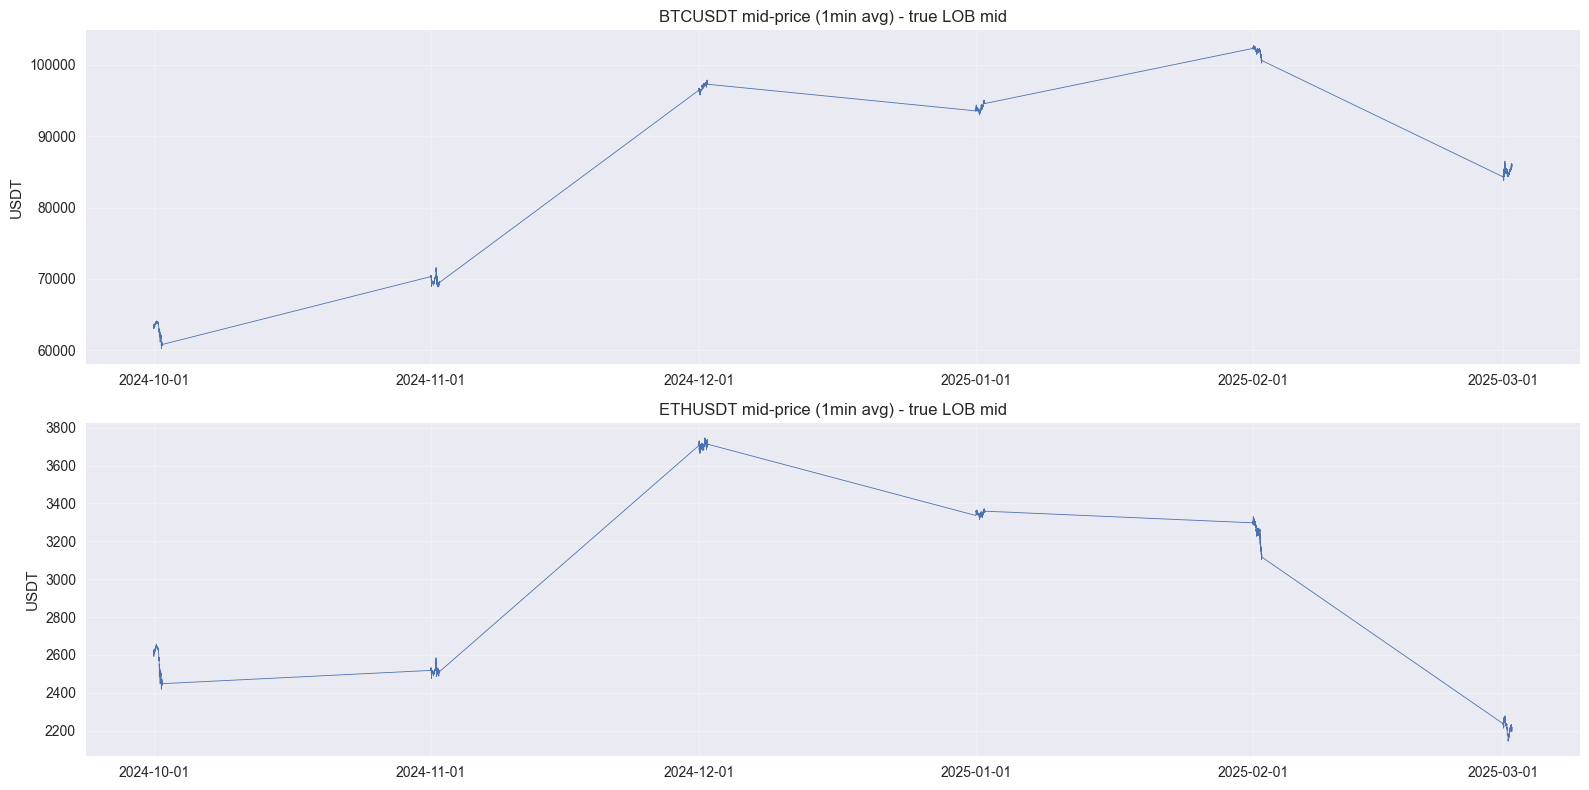

In [16]:
if mid_series:
    fig, axes = plt.subplots(len(SYMBOLS), 1, figsize=(16, 4 * len(SYMBOLS)))
    if len(SYMBOLS) == 1:
        axes = [axes]
    for ax, symbol in zip(axes, SYMBOLS):
        if symbol not in mid_series:
            continue
        m = mid_series[symbol].resample("1min").mean().dropna()
        ax.plot(m.index, m.values, lw=0.6)
        ax.set_title(f"{symbol} mid-price (1min avg) - true LOB mid")
        ax.set_ylabel("USDT")
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    plt.tight_layout()
    plt.show()

### Daily $\sigma$

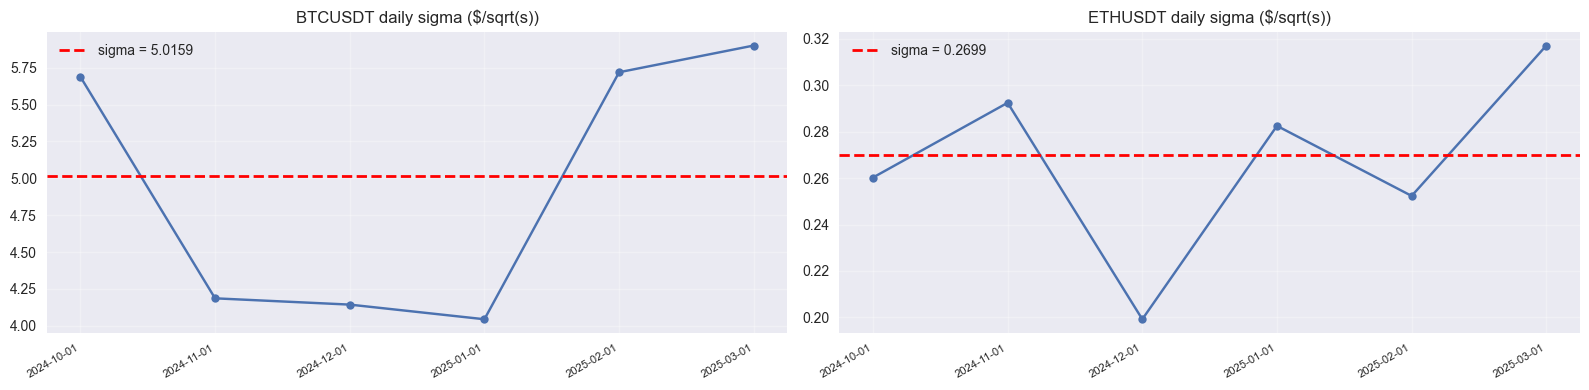

In [17]:
if fit_cache:
    fig, axes = plt.subplots(1, len(SYMBOLS), figsize=(8 * len(SYMBOLS), 4))
    if len(SYMBOLS) == 1:
        axes = [axes]
    for ax, symbol in zip(axes, SYMBOLS):
        if symbol not in fit_cache:
            continue
        ds    = fit_cache[symbol]["daily_sigma"]
        dates = pipeline_results[symbol]["processed_dates"]
        ax.plot(ds, "o-", ms=6)
        ax.axhline(calibrated[symbol]["sigma"], color="red", ls="--", lw=2,
                   label=f"sigma = {calibrated[symbol]['sigma']:.4f}")
        ax.set_xticks(range(len(ds)))
        ax.set_xticklabels(dates, rotation=30, ha="right", fontsize=8)
        ax.set_title(f"{symbol} daily sigma ($/sqrt(s))")
        ax.grid(True, alpha=0.3)
        ax.legend()
    plt.tight_layout()
    plt.show()

### Hypothetical-quote intensity fit: ask and bid sides

The key diagnostic plot.  For each $\delta_j$ the empirical dot is
$\hat\Lambda(\delta_j) = N_j / E_j$ (hits per second of passive exposure),
and the fitted line is $A\,e^{-k\delta_j}$.

Unlike the previous version (which only had points at the observed
half-spread), this plot spans a **range of quote distances** chosen by a
hypothetical market maker.

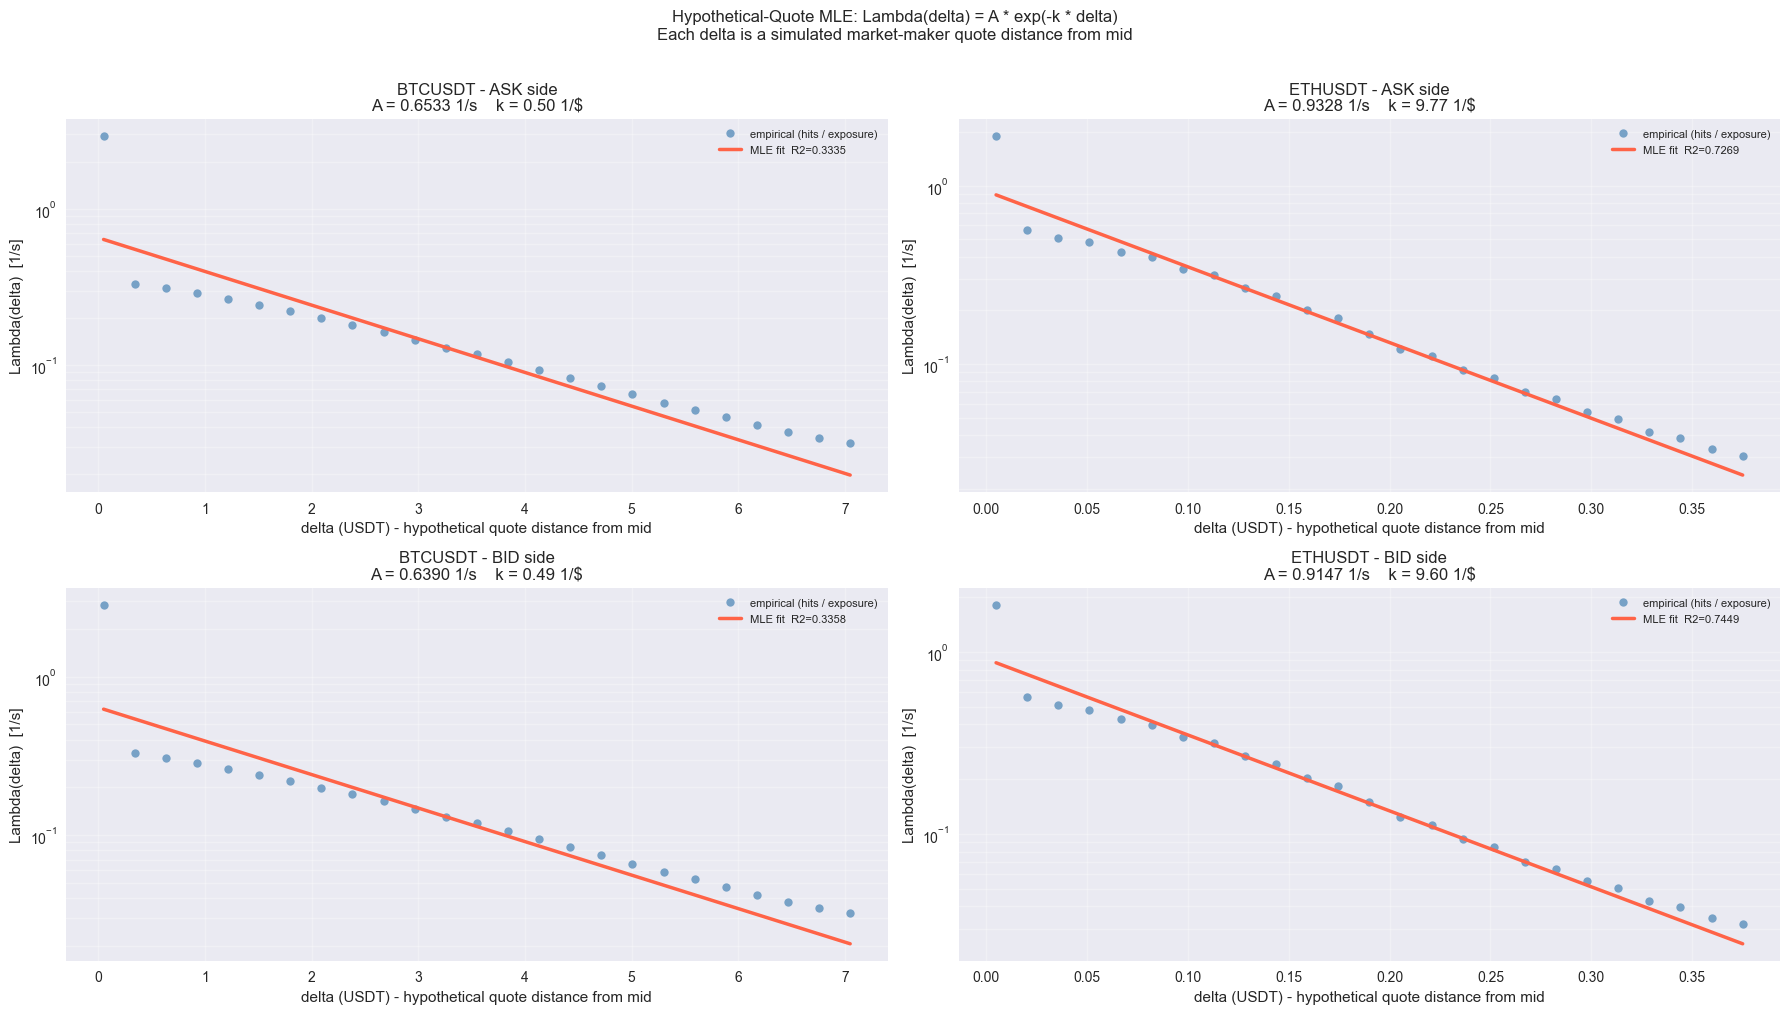

In [18]:
if fit_cache:
    fig, axes = plt.subplots(2, len(SYMBOLS), figsize=(9 * len(SYMBOLS), 10))
    if len(SYMBOLS) == 1:
        axes = axes.reshape(2, 1)

    for col, symbol in enumerate(SYMBOLS):
        if symbol not in fit_cache:
            continue
        fc = fit_cache[symbol]
        dg = fc["delta_grid"]

        for row, (side, lam_emp, lam_fit, r2_key) in enumerate([
            ("ASK", fc["lam_emp_ask"], fc["lam_fit_ask"], "r_squared_ask"),
            ("BID", fc["lam_emp_bid"], fc["lam_fit_bid"], "r_squared_bid"),
        ]):
            ax  = axes[row, col]
            r2  = calibrated[symbol][r2_key]
            A_s = calibrated[symbol][f"A_{side.lower()}"]
            k_s = calibrated[symbol][f"k_{side.lower()}"]

            valid = lam_emp > 0
            ax.semilogy(dg[valid], lam_emp[valid], "o",
                        ms=6, alpha=0.7, color="steelblue",
                        label="empirical (hits / exposure)")
            ax.semilogy(dg, lam_fit, "-", lw=2.5, color="tomato",
                        label=f"MLE fit  R2={r2:.4f}")
            ax.set_title(
                f"{symbol} - {side} side\n"
                f"A = {A_s:.4f} 1/s    k = {k_s:.2f} 1/$"
            )
            ax.set_xlabel("delta (USDT) - hypothetical quote distance from mid")
            ax.set_ylabel("Lambda(delta)  [1/s]")
            ax.grid(True, alpha=0.3, which="both")
            ax.legend(fontsize=8)

    plt.suptitle(
        "Hypothetical-Quote MLE: Lambda(delta) = A * exp(-k * delta)\n"
        "Each delta is a simulated market-maker quote distance from mid",
        fontsize=12, y=1.01,
    )
    plt.tight_layout()
    plt.show()

## 15. Final Parameter Summary

In [19]:
print("=" * 65)
print("CALIBRATED PARAMETERS - Gueant Model")
print("Method: Hypothetical-quote Poisson MLE (Gueant 2017 S6)")
print("Source: Tardis.dev binance-futures L1 + trades")
print("=" * 65)

for symbol in SYMBOLS:
    if symbol not in calibrated:
        continue
    p = calibrated[symbol]
    print(f"\n{symbol}")
    print(f"  sigma       = {p['sigma']:.6f}  $/sqrt(s)")
    print(f"  A (avg)     = {p['A']:.6f}  1/s   intensity at delta=0")
    print(f"    A_ask MLE = {p.get('A_ask',0):.6f}  k_ask = {p.get('k_ask',0):.4f}")
    print(f"    A_bid MLE = {p.get('A_bid',0):.6f}  k_bid = {p.get('k_bid',0):.4f}")
    print(f"  k (avg)     = {p['k']:.6f}  1/$   exponential decay")
    print(f"  Delta       = {p['Delta']:.2f}      $")
    print(f"  R2 (avg)    = {p['r_squared']:.4f}")
    print(f"  d*(q=0)     = {p.get('d_static',float('nan')):.6f}  USDT")
    print(f"  spread_0    = {p.get('spread_0',float('nan')):.6f}  USDT")
    print(f"  n_trades    = {p['n_trades']:,}")
    print(f"  n_days      = {p['n_days']}  ({p['period']})")

if "rho" in calibrated:
    print(f"\nrho(BTC, ETH) = {calibrated['rho']:.4f}")

print("\n" + "=" * 65)

CALIBRATED PARAMETERS - Gueant Model
Method: Hypothetical-quote Poisson MLE (Gueant 2017 S6)
Source: Tardis.dev binance-futures L1 + trades

BTCUSDT
  sigma       = 5.015861  $/sqrt(s)
  A (avg)     = 0.646151  1/s   intensity at delta=0
    A_ask MLE = 0.653303  k_ask = 0.4958
    A_bid MLE = 0.638999  k_bid = 0.4871
  k (avg)     = 0.491463  1/$   exponential decay
  Delta       = 85.07      $
  R2 (avg)    = 0.3347
  d*(q=0)     = 2.034566  USDT
  spread_0    = 4.164846  USDT
  n_trades    = 18,478,129
  n_days      = 6  (2024-10-01 -> 2025-03-01)

ETHUSDT
  sigma       = 0.269903  $/sqrt(s)
  A (avg)     = 0.923777  1/s   intensity at delta=0
    A_ask MLE = 0.932846  k_ask = 9.7717
    A_bid MLE = 0.914707  k_bid = 9.6043
  k (avg)     = 9.688005  1/$   exponential decay
  Delta       = 29.33      $
  R2 (avg)    = 0.7359
  d*(q=0)     = 0.103220  USDT
  spread_0    = 0.207010  USDT
  n_trades    = 25,699,734
  n_days      = 6  (2024-10-01 -> 2025-03-01)

rho(BTC, ETH) = 0.9182



---

## Methodological note (for report)

> We calibrate the passive fill intensity by simulating hypothetical limit
> orders at distances $\delta$ from the observed mid-price and measuring,
> for each $\delta$, both passive exposure time and whether subsequent
> aggressive trades would have reached that quote.  This yields an
> empirical intensity curve $\hat\Lambda(\delta)$, which we fit with the
> exponential specification $A\,e^{-k\delta}$ by Poisson maximum
> likelihood.
>
> Since only L1 order-book data is available and queue position is
> unobserved, the estimated $A$ and $k$ should be interpreted as
> reduced-form passive execution parameters rather than exact fill
> intensities for an individual market maker.